# Network Intrusion Detection System
An end-to-end Machine Learning pipeline built with **PySpark** and **Docker** to detect malicious network flows using the CSE-CIC-IDS-2018 dataset.

## Model Performance
After identifying and mitigating feature leakage, the GBT model achieved:
* **Recall**: 0.9982 (Prioritized to minimize false negatives in threat detection)
* **Precision**: 0.9982
* **F1-Score**: 0.9982

## Getting Started
1. **Launch the environment**:
   ```bash
   docker compose up -d
   docker compose logs ml-workspace
   ```

2. **Open the ipynb and connect to Spark kernel**
Add existing Jupyter kernel and copy "http://127.0.0.1:8888/lab?token=YOUR_TOKEN" 

# Initial Dataset Exploration
Testing on small dataset: the IDS 2018 Intrusion CSVs (CSE-CIC-IDS2018) on Kaggle

## Loading datasets

In [1]:
from pyspark.sql import SparkSession

# Initialize Spark Session
spark = SparkSession.builder \
    .appName("IDS_Intrusion_Detection") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .config("spark.memory.offHeap.enabled", "true") \
    .config("spark.memory.offHeap.size", "2g") \
    .getOrCreate()

# Load the specific day dataset
file_path = "data/ids2018kaggle/02-15-2018.csv"
df = spark.read.csv(file_path, header=True, inferSchema=True)

# Verify the load and check the row count
print(f"Total Rows: {df.count()}")

# Show the first 5 rows to confirm it loaded correctly
df.show(5)

Total Rows: 1048575
+--------+--------+-------------------+-------------+------------+------------+---------------+---------------+---------------+---------------+----------------+---------------+---------------+---------------+----------------+---------------+----------------+--------------+-------------+----------------+------------+------------+-----------+----------------+----------------+-----------+-----------+-----------+----------------+----------------+-----------+-----------+-------------+-------------+-------------+-------------+--------------+--------------+--------------+------------+-----------+-----------+--------------+--------------+---------------+------------+------------+------------+------------+------------+------------+--------------+------------+-------------+------------+----------------+----------------+--------------+--------------+----------------+--------------+--------------+----------------+----------------+----------------+----------------+--------------

In [2]:
import pyspark.sql.functions as F

df.select(F.mean("Flow Duration")).show() # Mean

+--------------------+
|  avg(Flow Duration)|
+--------------------+
|1.4307393660118733E7|
+--------------------+



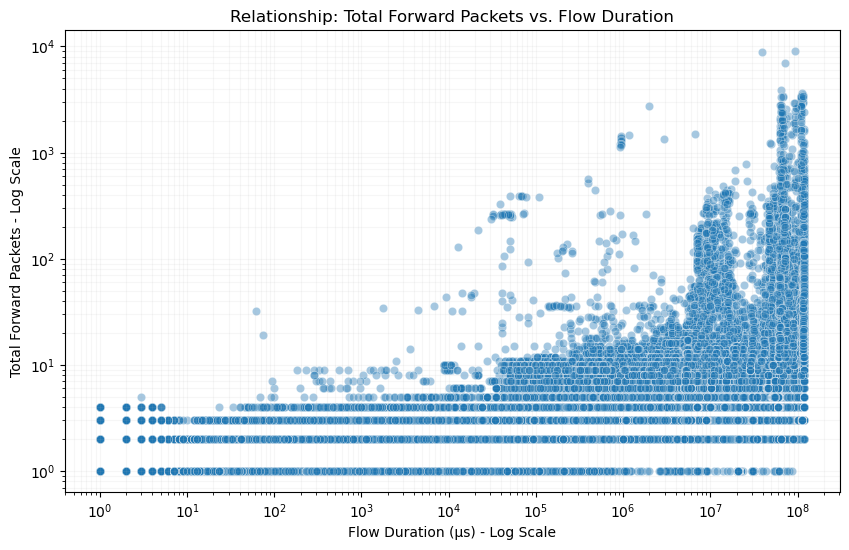

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_packets_vs_duration(df):
    # Sample 1% of the data to keep the plot responsive and avoid overplotting
    sample_pd = df.select("Flow Duration", "Tot Fwd Pkts").toPandas()

    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=sample_pd, x="Flow Duration", y="Tot Fwd Pkts", alpha=0.4)
    
    # Log scales since it's skewed
    plt.xscale('log')
    plt.yscale('log')
    
    plt.title("Relationship: Total Forward Packets vs. Flow Duration")
    plt.xlabel("Flow Duration (μs) - Log Scale")
    plt.ylabel("Total Forward Packets - Log Scale")
    plt.grid(True, which="both", ls="-", alpha=0.1)
    plt.show()

plot_packets_vs_duration(df)

In [4]:
df.limit(5).toPandas() # For better representation

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,15/02/2018 08:25:18,112641158,3,0,0,0,0,0,...,0,0.0,0.000000,0,0,56320579.0,7.042784e+02,56321077,56320081,Benign
1,22,6,15/02/2018 08:29:05,37366762,14,12,2168,2993,712,0,...,32,1024353.0,649038.754495,1601183,321569,11431221.0,3.644991e+06,15617415,8960247,Benign
2,47514,6,15/02/2018 08:29:42,543,2,0,64,0,64,0,...,32,0.0,0.000000,0,0,0.0,0.000000e+00,0,0,Benign
3,0,0,15/02/2018 08:28:07,112640703,3,0,0,0,0,0,...,0,0.0,0.000000,0,0,56320351.5,3.669884e+02,56320611,56320092,Benign
4,0,0,15/02/2018 08:30:56,112640874,3,0,0,0,0,0,...,0,0.0,0.000000,0,0,56320437.0,7.198347e+02,56320946,56319928,Benign


## Preprocessing data

In [5]:
import pyspark.sql.functions as F
print(f"Rows before cleaning: {df.count()}")

Rows before cleaning: 1048575


In [6]:
# Get uniformed column name
cleaned_columns = [c.strip() for c in df.columns]
df = df.toDF(*cleaned_columns)

In [7]:
df = df.replace(float('inf'), None) \
       .replace(float('-inf'), None) \
       .replace('Infinity', None) \
       .replace('-Infinity', None) \
       .replace('NaN', None) \
       .replace('nan', None) \
       .replace('', None)

df = df.dropna()
print(f"Rows after cleaning: {df.count()}")

Rows after cleaning: 1040548


## Dataset Exploration

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import col, when

print("Raw Label Distribution")
raw_counts = df.groupBy("Label").count().orderBy("count", ascending=False)
raw_counts.show(truncate=False)

# Binary classified Benign vs others
df = df.withColumn("Binary_Label", when(col("Label") == "Benign", "Benign").otherwise("Attack"))

def bin_dist_visual(df):

    print("Binary Label Distribution")
    binary_counts = df.groupBy("Binary_Label").count().toPandas()
    print(binary_counts.to_string(index=False))

    plt.figure(figsize=(8, 5))
    sns.barplot(data=binary_counts, x='Binary_Label', y='count', palette=['#2ecc71', '#e74c3c'])
    plt.title("Class Imbalance: Benign vs. Malicious Network Flows")
    plt.xlabel("Traffic Type")
    plt.ylabel("Number of Network Flows")
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)))) 
    plt.show()

Raw Label Distribution
+---------------------+------+
|Label                |count |
+---------------------+------+
|Benign               |988050|
|DoS attacks-GoldenEye|41508 |
|DoS attacks-Slowloris|10990 |
+---------------------+------+



Binary Label Distribution
Binary_Label  count
      Benign 988050
      Attack  52498


/tmp/ipykernel_101/1741252539.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=binary_counts, x='Binary_Label', y='count', palette=['#2ecc71', '#e74c3c'])


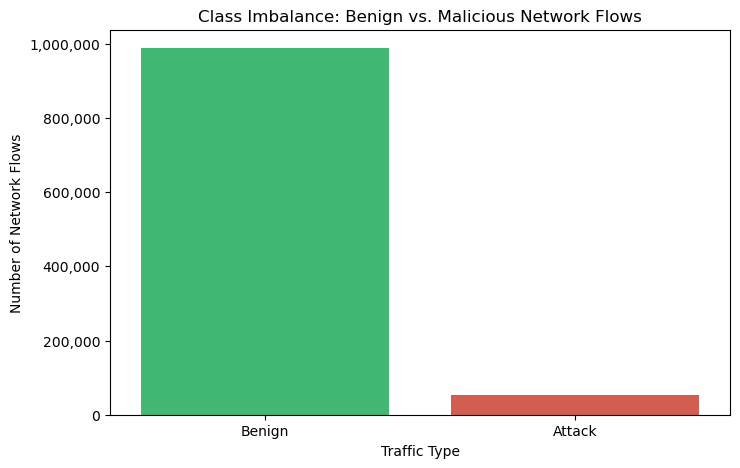

In [9]:
bin_dist_visual(df)

## Undersampling the Benign class

In [10]:
benign_df = df.filter(col("Binary_Label") == "Benign")
attack_df = df.filter(col("Binary_Label") == "Attack")

benign_count = benign_df.count()
attack_count = attack_df.count()

# compare benign to attack
fraction = attack_count / benign_count

# Random sampling the Benign traffic down to that fraction
undersampled_benign_df = benign_df.sample(withReplacement=False, fraction=fraction, seed=42)

balanced_df = undersampled_benign_df.union(attack_df)

print("New Balanced Distribution")
balanced_df.groupBy("Binary_Label").count().show()

New Balanced Distribution
+------------+-----+
|Binary_Label|count|
+------------+-----+
|      Benign|52722|
|      Attack|52498|
+------------+-----+



Binary Label Distribution
Binary_Label  count
      Benign  52722
      Attack  52498


/tmp/ipykernel_101/1741252539.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=binary_counts, x='Binary_Label', y='count', palette=['#2ecc71', '#e74c3c'])


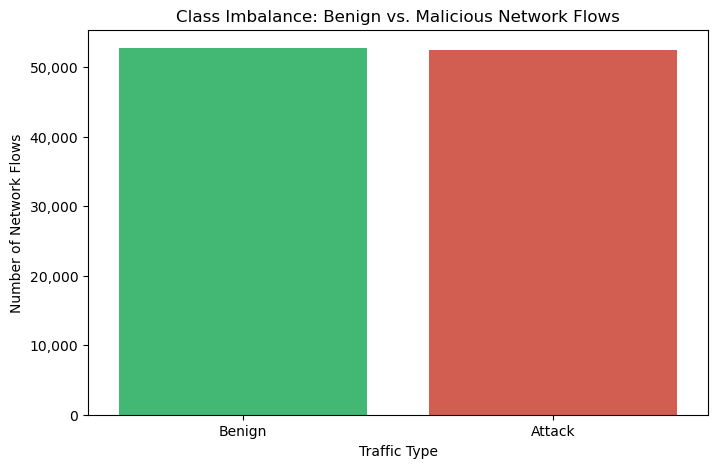

In [11]:
bin_dist_visual(balanced_df)

In [12]:
from pyspark.ml.feature import VectorAssembler
from pyspark.sql.types import DoubleType, StringType
# Convert str to bin int, attack = 1, benign = 0
balanced_df = balanced_df.withColumn("target_label", when(col("Binary_Label") == "Attack", 1).otherwise(0).cast(DoubleType()))
columns_to_drop = [f.name for f in balanced_df.schema.fields if isinstance(f.dataType, StringType)] # Non-numeric and redundant columns

In [13]:
cleaned_df = balanced_df.drop(*[c for c in columns_to_drop if c in balanced_df.columns])
# Obtained after running the code once and find the deterministic features
columns_to_drop = [
    'Label', 'Binary_Label', 'Timestamp', 
    'Fwd Seg Size Min', 'Dst Port', 'Protocol'
] 
cleaned_df = balanced_df.drop(*[c for c in columns_to_drop if c in balanced_df.columns])
cleaned_df.dropna()

DataFrame[Flow Duration: int, Tot Fwd Pkts: int, Tot Bwd Pkts: int, TotLen Fwd Pkts: int, TotLen Bwd Pkts: int, Fwd Pkt Len Max: int, Fwd Pkt Len Min: int, Fwd Pkt Len Mean: double, Fwd Pkt Len Std: double, Bwd Pkt Len Max: int, Bwd Pkt Len Min: int, Bwd Pkt Len Mean: double, Bwd Pkt Len Std: double, Flow Byts/s: double, Flow Pkts/s: double, Flow IAT Mean: double, Flow IAT Std: double, Flow IAT Max: int, Flow IAT Min: int, Fwd IAT Tot: int, Fwd IAT Mean: double, Fwd IAT Std: double, Fwd IAT Max: int, Fwd IAT Min: int, Bwd IAT Tot: int, Bwd IAT Mean: double, Bwd IAT Std: double, Bwd IAT Max: int, Bwd IAT Min: int, Fwd PSH Flags: int, Bwd PSH Flags: int, Fwd URG Flags: int, Bwd URG Flags: int, Fwd Header Len: int, Bwd Header Len: int, Fwd Pkts/s: double, Bwd Pkts/s: double, Pkt Len Min: int, Pkt Len Max: int, Pkt Len Mean: double, Pkt Len Std: double, Pkt Len Var: double, FIN Flag Cnt: int, SYN Flag Cnt: int, RST Flag Cnt: int, PSH Flag Cnt: int, ACK Flag Cnt: int, URG Flag Cnt: int, CWE

In [14]:
feature_columns = [col_name for col_name in cleaned_df.columns if col_name != 'target_label']
assembler = VectorAssembler(inputCols=feature_columns, outputCol="features")
cleaned_df = assembler.transform(cleaned_df)
cleaned_df.select("features", "target_label").show(5, truncate=False)

+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------------+
|features                                                                                                                                                                                                                                                                                                                                                                                               

## Model Training & Evaluation

In [ ]:
from pyspark.ml.classification import GBTClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

In [16]:
train_data, test_data = cleaned_df.randomSplit([0.8, 0.2], seed=42) # 80/20 split
train_data.cache() # Locking training data into RAM to prevent memory crash
print(f"Training Data Rows: {train_data.count()}")
print(f"Testing Data Rows: {test_data.count()}")

Training Data Rows: 84529
Testing Data Rows: 20691


In [ ]:
# save for scikit-learn 
#train_data.toPandas().to_csv('train.csv')
#test_data.toPandas().to_csv('test.csv')

In [18]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Logistic Regression with L2 Regularization baseline
# regParam as lambda. elasticNetParam=0.0 for L2.
lr = LogisticRegression(
    featuresCol="features", 
    labelCol="target_label", 
    maxIter=20, 
    regParam=0.1, 
    elasticNetParam=0.0
)

print("Training Baseline Logistic Regression...")
lr_model = lr.fit(train_data)

# Make Predictions on the Test Set
print("Evaluating Baseline on Test Set...")
lr_predictions = lr_model.transform(test_data)

evaluator = MulticlassClassificationEvaluator(
    labelCol="target_label", 
    predictionCol="prediction"
)

accuracy = evaluator.evaluate(lr_predictions, {evaluator.metricName: "accuracy"})
weighted_precision = evaluator.evaluate(lr_predictions, {evaluator.metricName: "weightedPrecision"})
weighted_recall = evaluator.evaluate(lr_predictions, {evaluator.metricName: "weightedRecall"})

print(f"\n--- Baseline Model Performance ---")
print(f"Logistic Regression (L2) Accuracy: {accuracy:.4f}")
print(f"Logistic Regression (L2) Precision: {weighted_precision:.4f}")
print(f"Logistic Regression (L2) Recall: {weighted_recall:.4f}")

Training Baseline Logistic Regression...
Evaluating Baseline on Test Set...

--- Baseline Model Performance ---
Logistic Regression (L2) Accuracy: 0.8741
Logistic Regression (L2) Precision: 0.8754
Logistic Regression (L2) Recall: 0.8741


In [19]:
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, mean_squared_error

# Spark back to panda, svc is slow for large data so we only take fraction
print("Converting a sample of Spark data to Pandas for SVC...")
train_pd = train_data.sample(fraction=0.01, seed=42).toPandas() 
test_pd = test_data.toPandas()

# extract feature column containing Spark Vector objects
X_train = np.stack(train_pd['features'].apply(lambda x: x.toArray()))
y_train = train_pd['target_label']

X_test = np.stack(test_pd['features'].apply(lambda x: x.toArray()))
y_test = test_pd['target_label']

# Train with C=1.0
print("Training SVC (this may take a few minutes)...")
svc_model = SVC(C=1.0, kernel='rbf', probability=True) 
svc_model.fit(X_train, y_train)

print("Evaluating SVC on Test Set...")
svc_preds = svc_model.predict(X_test)

accuracy = accuracy_score(y_test, svc_preds)
precision = precision_score(y_test, svc_preds)
recall = recall_score(y_test, svc_preds)

print(f"\n--- SVC Exploratory Model Performance ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")

Converting a sample of Spark data to Pandas for SVC...
Training SVC (this may take a few minutes)...
Evaluating SVC on Test Set...

--- SVC Exploratory Model Performance ---
Accuracy:  0.8233
Precision: 0.9173
Recall:    0.7119


In [20]:
gbt = GBTClassifier(featuresCol="features", labelCol="target_label", maxIter=20)
print("\nTraining GBT Model")
gbt_model = gbt.fit(train_data)
print("Training successfully!")


Training GBT Model
Training successfully!


In [21]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
print("Making predictions on test data...")
predictions = gbt_model.transform(test_data)

# Init the evaluator
gbt_evaluator = MulticlassClassificationEvaluator(
    labelCol="target_label", 
    predictionCol="prediction", 
    metricName="weightedRecall"
)

# Metrics
gbt_recall = gbt_evaluator.evaluate(predictions)
gbt_precision = gbt_evaluator.setMetricName("weightedPrecision").evaluate(predictions)
gbt_accuracy = gbt_evaluator.setMetricName("accuracy").evaluate(predictions)

print(f"\n--- GBT Model Performance ---")
print(f"Recall: {gbt_recall:.4f}")
print(f"Precision: {gbt_precision:.4f}")
print(f"Accuracy: {gbt_accuracy:.4f}")

predictions.select("target_label", "prediction", "probability").show(10)

Making predictions on test data...

--- GBT Model Performance ---
Recall: 0.9991
Precision: 0.9991
Accuracy: 0.9991
+------------+----------+--------------------+
|target_label|prediction|         probability|
+------------+----------+--------------------+
|         0.0|       0.0|[0.85835804320088...|
|         0.0|       0.0|[0.95072797765587...|
|         0.0|       0.0|[0.95072797765587...|
|         0.0|       0.0|[0.95072797765587...|
|         0.0|       0.0|[0.95072797765587...|
|         0.0|       0.0|[0.95072797765587...|
|         0.0|       0.0|[0.95072797765587...|
|         0.0|       0.0|[0.95635347857270...|
|         0.0|       0.0|[0.95084566784786...|
|         0.0|       0.0|[0.95084566784786...|
+------------+----------+--------------------+
only showing top 10 rows



In [22]:
malicious_recall = gbt_evaluator.setMetricLabel(1.0).setMetricName("recallByLabel").evaluate(predictions)

# Recall for the Benign class specifically (assuming 0.0 is Benign)
benign_recall = gbt_evaluator.setMetricLabel(0.0).setMetricName("recallByLabel").evaluate(predictions)

print(f"Recall for Benign: {benign_recall:.4f}")
print(f"Recall for Malicious: {malicious_recall:.4f}")

Recall for Benign: 0.9991
Recall for Malicious: 0.9990


Since we get a perfect score here, it seems that there's data leakage from the train set to the test set

In [23]:
import pandas as pd

importances = gbt_model.featureImportances.toArray()
feature_list = feature_columns
feature_imp_df = pd.DataFrame(list(zip(feature_list, importances)), columns=["Feature", "Importance"]).sort_values(by="Importance", ascending=False)

print("Top 10 Most Important Features:")
print(feature_imp_df.head(10))

Top 10 Most Important Features:
              Feature  Importance
64  Init Fwd Win Byts    0.302549
23        Fwd IAT Min    0.193123
14        Flow Pkts/s    0.177587
33     Fwd Header Len    0.083655
34     Bwd Header Len    0.076551
2        Tot Bwd Pkts    0.063318
65  Init Bwd Win Byts    0.031585
16       Flow IAT Std    0.031476
17       Flow IAT Max    0.008865
6     Fwd Pkt Len Min    0.005927


We see that:
Top 10 Most Important Features:
             Feature    Importance
69  Fwd Seg Size Min  9.660011e-01
0           Dst Port  3.258153e-02
44      FIN Flag Cnt  1.370536e-03
2      Flow Duration  1.857253e-05
4       Tot Bwd Pkts  8.530999e-06
25       Fwd IAT Min  8.156947e-06
16       Flow Pkts/s  6.316532e-06
17     Flow IAT Mean  3.118895e-06
3       Tot Fwd Pkts  2.147698e-06
6    TotLen Bwd Pkts  1.140383e-13

So the Fwd Seg Size Min is the deterministic indicator for the attack, let's drop this column

# Comparing the 3 models


In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from pyspark.sql.functions import udf
from pyspark.sql.types import FloatType

extract_prob = udf(lambda x: float(x[1]), FloatType()) # Udf to extract probabilities from PySpark vector

# 1. Baseline Logistic Regression L2
print("Processing Baseline LR probabilities...")
lr_preds_pd = lr_predictions.select(
    "target_label",
    extract_prob("probability").alias("prob_1")
).toPandas()
fpr_lr, tpr_lr, _ = roc_curve(lr_preds_pd['target_label'], lr_preds_pd['prob_1'])
roc_auc_lr = auc(fpr_lr, tpr_lr)

# 2. Exploratory Support Vector Machine
print("Processing SVC probabilities...")
# svc_model is in Scikit-Learn, so we use predict_proba on X_test
svc_probs = svc_model.predict_proba(X_test)[:, 1]

fpr_svc, tpr_svc, _ = roc_curve(y_test, svc_probs)
roc_auc_svc = auc(fpr_svc, tpr_svc)

# 3. Model of choice Gradient Boosting Tree
print("Processing GBT probabilities...")
# Extract probabilities from your 'predictions' PySpark dataframe
gbt_preds_pd = predictions.select(
    "target_label",
    extract_prob("probability").alias("prob_1")
).toPandas()

fpr_gbt, tpr_gbt, _ = roc_curve(gbt_preds_pd['target_label'], gbt_preds_pd['prob_1'])
roc_auc_gbt = auc(fpr_gbt, tpr_gbt)



Processing Baseline LR probabilities...
Processing SVC probabilities...
Processing GBT probabilities...


Generating ROC Curve plot...


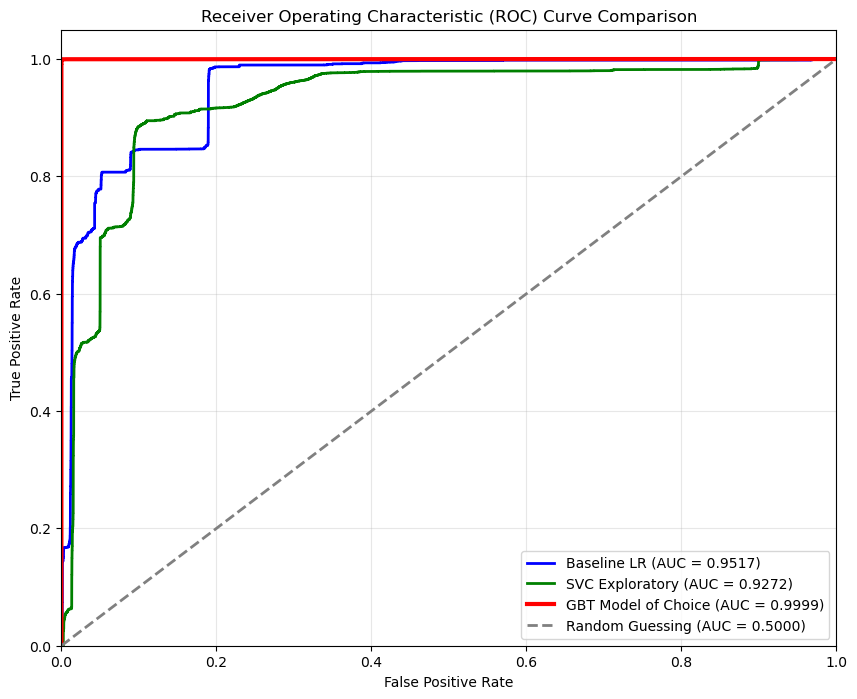

In [25]:
# ROC curve
print("Generating ROC Curve plot...")
plt.figure(figsize=(10, 8))

# Plot the lines for each model
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Baseline LR (AUC = {roc_auc_lr:.4f})')
plt.plot(fpr_svc, tpr_svc, color='green', lw=2, label=f'SVC Exploratory (AUC = {roc_auc_svc:.4f})')
plt.plot(fpr_gbt, tpr_gbt, color='red', lw=3, label=f'GBT Model of Choice (AUC = {roc_auc_gbt:.4f})')

# Plot the "Random Guessing" diagonal line
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guessing (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()